# Live Prediction Pipeline — multi-model

End-to-end pipeline that takes refreshed observational data, builds the
anchor-day feature row using the chosen model's §3 logic, and scores its
persisted ensemble → calibrated integer-°F PMF + Kalshi 6-bucket aggregation.

**Pick a model with `MODEL = "v3"` or `MODEL = "v4"` in §1 below.** Each
choice has a different anchor (v3 = 1 PM local; v4 = midnight local), a
different feature set, and a different post-processing pipeline. All those
differences come from the model notebook itself — live_predict adapts via the
artifact JSON, no manual code edits.

**Prerequisite:** the chosen model must have been run top-to-bottom at least
once to populate `data/model_{MODEL}_artifacts/`.

## §1 — Pick a model and load its artifacts

In [ ]:
# === §1 — Pick a model and load its artifacts ===
# Switch MODEL between "v3" (1 PM anchor, hard-floor projection) and "v4"
# (midnight anchor, no hard-floor). Adding a future "v5" works the same way:
# create model_v5.ipynb with the same §3 cell indices + artifact-save, set
# MODEL = "v5" here.
MODEL = "v3"

import json
import subprocess
import sys
import time
from pathlib import Path
from datetime import datetime, timezone, timedelta

import requests
import joblib
import numpy as np
import pandas as pd

ART_DIR  = Path(f"data/model_{MODEL}_artifacts")
DATA_DIR = Path("data")

if not ART_DIR.exists():
    raise FileNotFoundError(
        f"{ART_DIR} not found. Run model_{MODEL}.ipynb end-to-end first to "
        f"populate it via the artifact-save cell."
    )

# Constants from the artifact snapshot
with open(ART_DIR / "constants.json") as f:
    _const = json.load(f)
MODEL_NAME            = _const.get("MODEL_NAME", MODEL)
if "HAS_HARD_FLOOR" not in _const:
    raise RuntimeError(
        f"constants.json in {ART_DIR} is missing 'HAS_HARD_FLOOR'. "
        f"This means the artifacts were saved BEFORE model_{MODEL}.ipynb's "
        f"artifact-save cell was updated to write that key. Open "
        f"model_{MODEL}.ipynb and re-run its LAST cell (artifact-save, ~1 sec) "
        f"to refresh constants.json, then re-run this cell. Predictions made "
        f"with stale constants silently SKIP the hard-floor projection and "
        f"are slightly biased."
    )
HAS_HARD_FLOOR        = bool(_const["HAS_HARD_FLOOR"])

# USE_CALIB_FOR_SEASONS: which seasons should apply the isotonic recalibration.
# Backward-compat default = ALL 4 seasons (matches old behavior). New v3
# artifacts (post §8.6 season-selective rollout) override this to ["JJA"] only.
USE_CALIB_FOR_SEASONS = set(_const.get("USE_CALIB_FOR_SEASONS", ["DJF", "MAM", "JJA", "SON"]))
FEATURE_COLS          = _const["FEATURE_COLS"]
QUANTILES             = _const["QUANTILES"]
INTEGER_F_GRID        = np.array(_const["INTEGER_F_GRID"], dtype=int)
SEASON_OF_MONTH       = {int(k): v for k, v in _const["SEASON_OF_MONTH"].items()}
SEEDS                 = _const["SEEDS"]
N_SEEDS               = _const["N_SEEDS"]
STATION               = _const["STATION"]
TARGET_COL            = _const["TARGET_COL"]
T_HOUR_LOCAL          = _const["T_HOUR_LOCAL"]
PEAK_START_HOUR_LOCAL = _const["PEAK_START_HOUR_LOCAL"]
PEAK_END_HOUR_LOCAL   = _const["PEAK_END_HOUR_LOCAL"]
LOCAL_TZ              = _const["LOCAL_TZ"]
START_DATE            = "01/01/2020"
TODAY                 = datetime.now(timezone.utc)

# Trained models + calibrators
final_models           = joblib.load(ART_DIR / "final_models.joblib")
isotonic_recalibrators = joblib.load(ART_DIR / "isotonic_recalibrators.joblib")
feature_df_reference   = pd.read_parquet(ART_DIR / "feature_df.parquet")

print(f"Loaded artifacts for model={MODEL_NAME!r} from {ART_DIR.resolve()}")
print(f"  hard floor:           {HAS_HARD_FLOOR}")
print(f"  T anchor:             {T_HOUR_LOCAL:02d}:00 local ({LOCAL_TZ})")
print(f"  peak window:          [{PEAK_START_HOUR_LOCAL}, {PEAK_END_HOUR_LOCAL})")
print(f"  final_models:         {len(final_models)} seeds × {len(final_models[0])} quantiles")
print(f"  recalibrators:        {list(isotonic_recalibrators)}")
print(f"  FEATURE_COLS:         {len(FEATURE_COLS)} cols")
print(f"  feature_df_reference: {feature_df_reference.shape}  "
      f"({feature_df_reference['date'].min().date()} -> {feature_df_reference['date'].max().date()})")


## §2 — Refresh data + extend cli/target_df

Calls `refresh_data.py` to bring METAR/TAF/ASOS/CLI parquets current. Picks
`ANCHOR_DATE` via `latest_viable_anchor()` (latest date where wall-clock is
past T_HOUR_LOCAL of that date AND all three observational streams cover
T_utc). Prints per-source freshness vs T_utc. Extends cli with a placeholder
row if needed. Pre-filters taf and target_df to a small window around
ANCHOR_DATE so §3 stays fast.

In [ ]:
# Refresh historical parquets (incremental, ~10-30s).
print("Refreshing IEM parquets via refresh_data.py ...")
_t0 = time.perf_counter()
_proc = subprocess.run(
    [sys.executable, "refresh_data.py"],
    capture_output=True, text=True, cwd=Path.cwd(),
)
print(_proc.stdout.strip())
if _proc.returncode != 0:
    print(_proc.stderr)
    raise RuntimeError("refresh_data.py failed")
print(f"  refresh wall time: {time.perf_counter() - _t0:.1f}s")

# A1 -- extend HRRR coverage to today. refresh_data.py only handles the IEM/NWS
# streams; HRRR has its own fetcher. Run backfill_hrrr.py for the last few days
# (resumable -- it skips dates already in the parquet, so this is usually just
# today's 12Z run + any gaps). Same code path as training => no feature drift.
print("\nExtending HRRR coverage via backfill_hrrr.py ...")
_hstart = (pd.Timestamp.now(tz=LOCAL_TZ).normalize() - pd.Timedelta(days=4)).strftime("%Y-%m-%d")
_hend   = pd.Timestamp.now(tz=LOCAL_TZ).normalize().strftime("%Y-%m-%d")
_t1 = time.perf_counter()
_hproc = subprocess.run(
    [sys.executable, "backfill_hrrr.py", "--start", _hstart, "--end", _hend, "--threads", "4"],
    capture_output=True, text=True, cwd=Path.cwd(),
)
# backfill prints a lot of warnings; show only its summary tail.
_htail = [ln for ln in _hproc.stdout.strip().split("\n")
          if any(k in ln for k in ("Resuming", "Fresh build", "Nothing to do",
                                    "Wrote", "Distinct dates", "Avg rows"))]
print("\n".join(_htail) if _htail else _hproc.stdout.strip()[-400:])
if _hproc.returncode != 0:
    print(f"  WARNING: backfill_hrrr.py returned {_hproc.returncode}; HRRR may be stale.")
    print("  " + _hproc.stderr.strip()[-400:])
print(f"  HRRR backfill wall time: {time.perf_counter() - _t1:.1f}s")

# Re-load parquets (now including HRRR)
metar = pd.read_parquet(DATA_DIR / f"metar_{STATION}.parquet")
taf   = pd.read_parquet(DATA_DIR / f"taf_{STATION}.parquet")
asos  = pd.read_parquet(DATA_DIR / f"asos_{STATION}.parquet")
cli   = pd.read_parquet(DATA_DIR / f"cli_{STATION}.parquet")
hrrr  = pd.read_parquet(DATA_DIR / f"hrrr_12z_{STATION}.parquet")


def _T_utc_for(date):
    """UTC instant of T_HOUR_LOCAL on a given local-time date."""
    return (pd.Timestamp(date).normalize().tz_localize(LOCAL_TZ)
            + pd.Timedelta(hours=T_HOUR_LOCAL)).tz_convert("UTC")


def latest_viable_anchor(metar, taf, asos, hrrr, now_local=None, max_lookback_days=30):
    """Latest local-time date where:
      (a) current local wall-clock is past T_HOUR_LOCAL of that date,
      (b) METAR, TAF, ASOS each have an observation at or after T_utc, AND
      (c) the HRRR parquet has rows for that date (the 12Z forecast covering
          the peak window). Without (c) the model loses all 17 HRRR features
          to NaN -- its most important signal block -- so HRRR coverage is a
          hard requirement for a usable anchor.
    Returns a naive (tz-stripped) pd.Timestamp normalized to midnight.
    """
    if now_local is None:
        now_local = pd.Timestamp.now(tz=LOCAL_TZ)
    metar_latest_utc = pd.to_datetime(metar["timestamp"], utc=True).max()
    taf_latest_utc   = pd.to_datetime(taf["valid"],     utc=True).max()
    asos_latest_utc  = pd.to_datetime(asos["timestamp"], utc=True).max()
    hrrr_dates = set(pd.to_datetime(hrrr["date"]).dt.normalize().unique())
    candidate = now_local.normalize()
    for _ in range(max_lookback_days + 1):
        T_utc = (candidate + pd.Timedelta(hours=T_HOUR_LOCAL)).tz_convert("UTC")
        past_T = now_local >= (candidate + pd.Timedelta(hours=T_HOUR_LOCAL))
        iem_fresh = (
            metar_latest_utc >= T_utc and
            taf_latest_utc   >= T_utc and
            asos_latest_utc  >= T_utc
        )
        hrrr_covered = candidate.tz_localize(None).normalize() in hrrr_dates
        if past_T and iem_fresh and hrrr_covered:
            return candidate.tz_localize(None).normalize()
        candidate -= pd.Timedelta(days=1)
    raise RuntimeError(
        f"No viable anchor in the past {max_lookback_days} days. Freshness: "
        f"METAR={metar_latest_utc}, TAF={taf_latest_utc}, ASOS={asos_latest_utc}, "
        f"HRRR_max={max(hrrr_dates) if hrrr_dates else None}"
    )


# === ANCHOR_DATE ===
# Default = latest date where IEM streams cover T_utc, HRRR covers the date,
# AND wall-clock is past T_local. Override AFTER this line to force another
# date, e.g.:  ANCHOR_DATE = pd.Timestamp("2026-05-22").normalize()
ANCHOR_DATE = latest_viable_anchor(metar, taf, asos, hrrr)
print(f"\nANCHOR_DATE = {ANCHOR_DATE.date()}  ({LOCAL_TZ}, T = {T_HOUR_LOCAL:02d}:00) "
      f"[latest with IEM + HRRR coverage; override below for another date]")

# Per-source freshness vs T_utc of the chosen ANCHOR_DATE
_T_utc = _T_utc_for(ANCHOR_DATE)
print(f"\nFreshness vs T_utc = {_T_utc}:")
for _nm, _df, _tcol in [("metar", metar, "timestamp"), ("taf", taf, "valid"),
                        ("asos", asos, "timestamp"), ("cli", cli, "date")]:
    _latest = pd.to_datetime(_df[_tcol], utc=True if _tcol != "date" else None).max()
    _latest_utc = pd.Timestamp(_latest).tz_localize("UTC") if _tcol == "date" else pd.Timestamp(_latest).tz_convert("UTC")
    _age_min = (_T_utc - _latest_utc).total_seconds() / 60
    _status = "OK" if _age_min <= 0 else f"STALE by {_age_min:>5.0f} min"
    print(f"  {_nm:5s}: latest = {str(_latest):30s}  {_status}")
# HRRR coverage is by date, not timestamp -- report it separately.
_hrrr_max = pd.to_datetime(hrrr["date"]).max().date()
_hrrr_ok = pd.Timestamp(ANCHOR_DATE).normalize() in set(pd.to_datetime(hrrr["date"]).dt.normalize().unique())
print(f"  {'hrrr':5s}: coverage to {_hrrr_max}  {'OK (anchor covered)' if _hrrr_ok else 'MISSING anchor date!'}")


# Extend cli with a placeholder row for ANCHOR_DATE so the §3.3 rolling/shift
# lookups (built by the chosen model's notebook) work cleanly. Skipped if
# ANCHOR_DATE already has CLI truth.
if pd.Timestamp(ANCHOR_DATE) not in pd.to_datetime(cli["date"]).values:
    _extra = pd.DataFrame({
        "station":    [STATION],
        "date":       [ANCHOR_DATE],
        "max_temp_f": pd.array([pd.NA], dtype="Int64"),
    })
    cli = pd.concat([cli, _extra], ignore_index=True).sort_values("date").reset_index(drop=True)
    print(f"\n  extended cli with placeholder row for {ANCHOR_DATE.date()} (cli now {len(cli)} rows)")
else:
    print(f"\n  cli already has truth for {ANCHOR_DATE.date()} (cli_high = "
          f"{int(cli.loc[pd.to_datetime(cli['date']) == pd.Timestamp(ANCHOR_DATE), 'max_temp_f'].iloc[0])}°F); no placeholder needed")


# Build target_df (don't dropna -- we may want the placeholder row).
target_df = (
    cli[["date", "max_temp_f"]]
    .rename(columns={"max_temp_f": "cli_high"})
    .drop_duplicates(subset=["date"], keep="first")
    .sort_values("date")
    .reset_index(drop=True)
)
_start = pd.to_datetime(START_DATE, format="%m/%d/%Y")
target_df = target_df[target_df["date"] >= _start].reset_index(drop=True)


# PERF: pre-filter taf to issuances overlapping the target window. The chosen
# model's §3.4 scans taf once per target date; trimming the table here turns
# those scans from 101k rows to <1k.
_KEEP_WINDOW_DAYS = 14
_keep_start = pd.Timestamp(ANCHOR_DATE) - pd.Timedelta(days=_KEEP_WINDOW_DAYS)
_taf_window_start_utc = (_keep_start.tz_localize(LOCAL_TZ) - pd.Timedelta(days=2)).tz_convert("UTC")
_taf_orig_n = len(taf)
taf = taf[taf["valid"] >= _taf_window_start_utc].reset_index(drop=True)
print(f"\n  taf pre-filtered to issuances >= {_taf_window_start_utc}: "
      f"{_taf_orig_n} -> {len(taf)} rows")

# PERF: filter target_df to the same window so §3.2 (astro) and §3.4 (TAF)
# only iterate ~14 dates. Runs AFTER the target_df build above so it actually
# applies.
target_df = target_df[target_df["date"] >= _keep_start].reset_index(drop=True)
print(f"  target_df filtered to last {_KEEP_WINDOW_DAYS} days "
      f"(>= {_keep_start.date()}): {len(target_df)} rows")


## §3 — Build today's feature row

Dynamically loads §3 cells (20/22/24/26/28/30/32) from `model_{MODEL}.ipynb` and execs them into globals. The chosen model owns its own feature engineering; live_predict adapts automatically.

If a model notebook's §3 structure is changed, the sanity check in the exec cell will raise a clear error before silently executing the wrong cells.

In [ ]:
# === §3 — Build today's feature row (dynamic-exec from the chosen model) ===
# Auto-discovers §3 subsections by scanning the chosen model's notebook for
# "### §3.X" markdown headers and exec'ing each one's following code cell.
# Adapts automatically when a model adds / removes / reorders §3 subsections
# (e.g. v3 has §3.1-§3.8 with HRRR; v4 has §3.1-§3.7 without). Zero drift.
SOURCE_NB = Path(f"model_{MODEL}.ipynb")
with open(SOURCE_NB, "r", encoding="utf-8") as _f:
    _src_nb = json.load(_f)

_s3_pairs = []  # list of (cell_idx, header_text)
for _i, _c in enumerate(_src_nb["cells"]):
    if _c["cell_type"] != "markdown":
        continue
    _first = "".join(_c["source"]).split("\n", 1)[0].strip()
    if _first.startswith("### §3."):
        for _j in range(_i + 1, len(_src_nb["cells"])):
            if _src_nb["cells"][_j]["cell_type"] == "code":
                _s3_pairs.append((_j, _first))
                break

if not _s3_pairs:
    raise RuntimeError(f"No '### §3.' subsection markdown headers found in {SOURCE_NB}")

print(f"Exec'ing §3 cells from {SOURCE_NB} ({len(_s3_pairs)} subsections):")
for _idx, _head in _s3_pairs:
    print(f"  [{_idx:>2}] {_head}")

_t0 = time.perf_counter()
for _idx, _ in _s3_pairs:
    _src = "".join(_src_nb["cells"][_idx]["source"])
    exec(compile(_src, f"<{SOURCE_NB}::cell{_idx}>", "exec"), globals())
print(f"\n  §3 wall time: {time.perf_counter() - _t0:.1f}s")
print(f"  feature_df: {feature_df.shape}  (columns: {len(feature_df.columns)})")


## §4 — Score the ensemble → calibrated PMF for ANCHOR_DATE

### §4.1 — Helpers (copied from model_v3 §6.1 & §8.x)

In [108]:
# Integer-F grid covering all plausible KMDW daily-max values with safe slack.
# Kalshi-style output is P(cli_high = X) for each integer X in this range.
INTEGER_F_GRID = np.arange(-30, 131, dtype=int)


def quantile_to_bucket_probs(q_levels, q_preds, F_grid=INTEGER_F_GRID):
    """Convert one row's quantile predictions into a probability distribution over integer F.

    Two-step pipeline:
      1. Sort the raw quantile predictions ascending to enforce monotonicity
         (Chernozhukov rearrangement -- provably never worse than the unsorted input).
      2. Treat the sorted (F, tau) pairs as points on the CDF and linearly
         interpolate to build a piecewise-linear CDF. Tails are anchored at
         (Q_min - 10, 0) and (Q_max + 10, 1) so the CDF reaches 0 below and 1
         above the support without leaving mass at infinity.

    For each integer F in F_grid, the bucket probability is
        P(cli_high = F) = CDF(F + 0.5) - CDF(F - 0.5)
    matching the same +/-0.5 rounding boundary CLI uses when converting
    its 0.1 deg C measurements to whole F.

    Args:
    - q_levels (np.ndarray): quantile levels, shape (n_q,), e.g. [0.02, 0.04, ..., 0.98].
    - q_preds (np.ndarray): predicted F values at those quantiles, shape (n_q,).
      Crossings are tolerated and sorted internally.
    - F_grid (np.ndarray): integer F values to evaluate bucket probabilities at.

    Returns:
    - np.ndarray of shape (len(F_grid),): bucket probabilities summing to ~1,
      or all-NaN if q_preds contained any NaN.
    """
    if np.isnan(q_preds).any():
        return np.full(len(F_grid), np.nan)
    # 1) sort to enforce monotonicity (rearrangement)
    q_sorted = np.sort(q_preds)
    # 2) anchor tails so CDF reaches 0 and 1
    F_anchor = np.concatenate([[q_sorted[0] - 10], q_sorted, [q_sorted[-1] + 10]])
    P_anchor = np.concatenate([[0.0],              q_levels, [1.0]])
    # CDF at bucket edges
    cdf_hi = np.interp(F_grid + 0.5, F_anchor, P_anchor)
    cdf_lo = np.interp(F_grid - 0.5, F_anchor, P_anchor)
    probs = np.clip(cdf_hi - cdf_lo, 0.0, None)
    total = probs.sum()
    if total > 0:
        probs = probs / total
    return probs


# Smoke test: synthetic monotone quantile predictions sized to len(QUANTILES).
_mock_q = np.linspace(55, 85, len(QUANTILES))
_mock_probs = quantile_to_bucket_probs(np.array(QUANTILES), _mock_q)
print(f"smoke test ({len(QUANTILES)} quantiles): probs.shape={_mock_probs.shape}  "
      f"sum={_mock_probs.sum():.6f}  argmax bucket = {INTEGER_F_GRID[_mock_probs.argmax()]}F")


smoke test (19 quantiles): probs.shape=(161,)  sum=1.000000  argmax bucket = 67F


In [109]:
def recalibrate_row(probs_row, recalibrators, season_key, F_grid=INTEGER_F_GRID):
    """Apply season-specific isotonic recalibration to one row's bucket probabilities.

    Looks up the season's recalibrator from `recalibrators` and applies it
    to the predicted CDF, then differences back to get new bucket probabilities.

    *** CALIBRATION CAVEAT (UNCHANGED FROM §8.1) ***
    These recalibrators were fit on OOF predictions from §5 (smaller training
    windows) but are applied to `final_models` output trained on the FULL
    feature_df (slightly sharper). Mild mis-specification; output will be
    slightly over-widened. For production deployment, fit on rolling-window
    OOF that matches the final model's training horizon. See §8.1 docstring
    for the principled HRRR/GFS feature roadmap that would reduce reliance
    on calibration entirely.

    Args:
    - probs_row (np.ndarray): single-row bucket probabilities, length len(F_grid).
    - recalibrators (dict): {"DJF": iso, "MAM": iso, "JJA": iso, "SON": iso}.
    - season_key (str): one of "DJF" / "MAM" / "JJA" / "SON"; pick via
      SEASON_OF_MONTH[date.month].
    - F_grid (np.ndarray): integer F values aligned with the bucket columns.

    Returns:
    - np.ndarray of shape (len(F_grid),): calibrated probabilities summing to ~1.
      All-NaN if probs_row contains any NaN or season_key is unknown.
    """
    if np.isnan(probs_row).any() or season_key not in recalibrators:
        return np.full(len(probs_row), np.nan)
    recalibrator = recalibrators[season_key]
    cdf_raw   = np.cumsum(probs_row)
    cdf_calib = recalibrator.predict(cdf_raw)
    new_probs = np.empty(len(probs_row))
    new_probs[0]  = cdf_calib[0]
    new_probs[1:] = np.diff(cdf_calib)
    new_probs = np.clip(new_probs, 0.0, None)
    s = new_probs.sum()
    return new_probs / s if s > 0 else new_probs


### §4.2 — Predict for ANCHOR_DATE

In [ ]:
def predict_for_anchor(anchor_date, feature_df_live):
    """Score the loaded ensemble on the feature row for `anchor_date`.

    Per-seed quantile -> per-seed PMF (Chernozhukov rearrangement) ->
    seed-average -> isotonic recalibration by season. If HAS_HARD_FLOOR is
    True AND the feature row has a non-null running_max_F_T_hard, applies
    the v3-style hard-floor projection (zeros mass below the floor + renorm).
    """
    target = pd.Timestamp(anchor_date).normalize()
    row_mask = (feature_df_live["date"] == target)
    if not row_mask.any():
        raise KeyError(f"No feature row for {target.date()} in feature_df_live")

    X = feature_df_live.loc[row_mask, FEATURE_COLS].astype("float64")
    nan_cols = X.columns[X.isna().any().values].tolist()
    if nan_cols:
        print(f"  WARNING: NaN in {len(nan_cols)} feature(s) for {target.date()}: {nan_cols}")

    q_levels = np.array(QUANTILES)

    # 1) per-seed quantile -> per-seed PMF
    seed_pmfs = np.zeros((len(final_models), len(INTEGER_F_GRID)))
    for s_idx, seed_models in enumerate(final_models):
        q_preds = np.array([m.predict(X)[0] for m in seed_models])
        seed_pmfs[s_idx] = quantile_to_bucket_probs(q_levels, q_preds)
    raw_probs = seed_pmfs.mean(axis=0)
    if raw_probs.sum() > 0:
        raw_probs = raw_probs / raw_probs.sum()

    # 2) per-season isotonic recalibration (season-selective per §8.6).
    # USE_CALIB_FOR_SEASONS controls which seasons get the recalibrator;
    # others pass through raw to preserve the §8.6 CRPS win.
    season_key = SEASON_OF_MONTH[target.month]
    if season_key in USE_CALIB_FOR_SEASONS:
        calib_probs = recalibrate_row(raw_probs, isotonic_recalibrators, season_key)
    else:
        calib_probs = raw_probs.copy()

    # 3) hard-floor projection (v3-style); skipped for v4 and any model
    #    without running_max_F_T_hard or with HAS_HARD_FLOOR=False.
    hard_floor_val = None
    leaked = 0.0
    if HAS_HARD_FLOOR and "running_max_F_T_hard" in feature_df_live.columns:
        hard_floor_val = feature_df_live.loc[row_mask, "running_max_F_T_hard"].iloc[0]
        if pd.notna(hard_floor_val):
            hf = int(hard_floor_val)
            below = INTEGER_F_GRID < hf
            leaked = float(calib_probs[below].sum())
            calib_probs[below] = 0.0
            if calib_probs.sum() > 0:
                calib_probs = calib_probs / calib_probs.sum()

    pmf = pd.Series(calib_probs, index=INTEGER_F_GRID, name="P")
    cdf = pmf.cumsum().values
    median  = int(INTEGER_F_GRID[np.searchsorted(cdf, 0.5)])
    lo10    = int(INTEGER_F_GRID[np.searchsorted(cdf, 0.10)])
    hi90    = int(INTEGER_F_GRID[np.searchsorted(cdf, 0.90)])
    peak_F  = int(pmf.idxmax())
    peak_P  = float(pmf.max())

    return {
        "date":         target,
        "model":        MODEL_NAME,
        "pmf":          pmf,
        "median":       median,
        "lo10":         lo10,
        "hi90":         hi90,
        "width_80pct":  hi90 - lo10,
        "peak_F":       peak_F,
        "peak_P":       peak_P,
        "season":       season_key,
        "hard_floor":   None if (hard_floor_val is None or pd.isna(hard_floor_val)) else int(hard_floor_val),
        "leaked_below_floor": leaked,
    }


_result = predict_for_anchor(ANCHOR_DATE, feature_df)

print(f"=== Calibrated PMF for {_result['date'].date()} ({_result['model']}) ===")
print(f"  season:       {_result['season']}")
if _result["hard_floor"] is not None:
    print(f"  hard floor:   {_result['hard_floor']}°F  "
          f"(mass below-floor zeroed: {_result['leaked_below_floor']:.4f})")
else:
    print(f"  hard floor:   (n/a — {_result['model']} has no hard-floor projection)")
print(f"  median:       {_result['median']}°F")
print(f"  80% CI:       [{_result['lo10']}, {_result['hi90']}]°F  (width {_result['width_80pct']}°F)")
print(f"  peak bucket:  P(high = {_result['peak_F']}°F) = {_result['peak_P']:.4f}")
print()
print(f"  Top 10 most-likely integer °F buckets:")
for f, p in _result["pmf"].sort_values(ascending=False).head(10).items():
    bar = "#" * int(p * 100)
    print(f"    P(high = {f}°F) = {p:.4f}  {bar}")


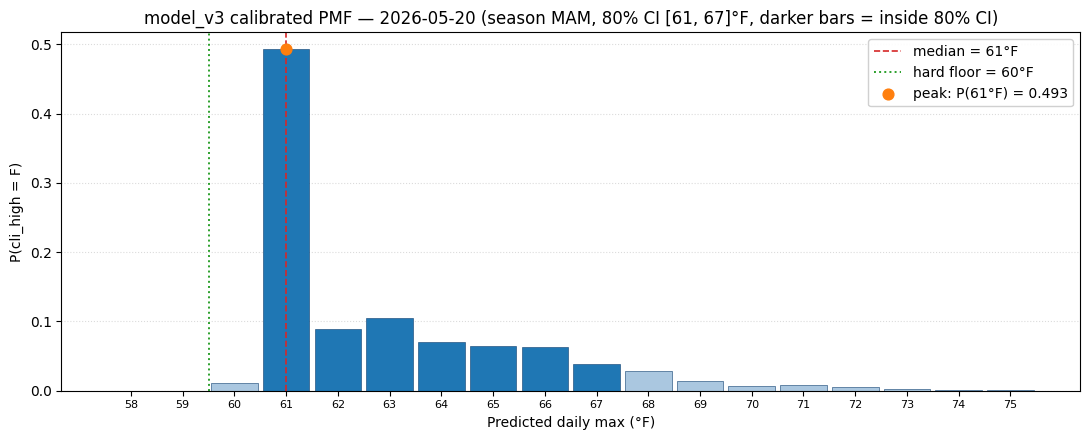

In [111]:
# === §4.3 Bar chart of the predicted PMF for ANCHOR_DATE ===
import matplotlib.pyplot as plt

_pmf = _result["pmf"]
# Find the bounding box of meaningful mass (P > 0.001) and clip the x-axis
# to that range with a small buffer. Avoids numerical-tail ghost bars at the
# grid edges (INTEGER_F_GRID spans -30..130, vastly wider than any real
# physical signal).
_significant = _pmf.index[_pmf.values > 0.001]
if len(_significant):
    _x_min = int(_significant.min()) - 2
    _x_max = int(_significant.max()) + 2
else:
    _x_min = int(_result["median"]) - 10
    _x_max = int(_result["median"]) + 10
_window_mask = (_pmf.index >= _x_min) & (_pmf.index <= _x_max)
_x = _pmf.index[_window_mask]
_y = _pmf.values[_window_mask]
_median = _result["median"]
_lo10, _hi90 = _result["lo10"], _result["hi90"]
_peak_F = _result["peak_F"]
_hard_floor = _result["hard_floor"]

fig, ax = plt.subplots(figsize=(11, 4.5))
colors = ["#1f77b4" if (_lo10 <= f <= _hi90) else "#aac7e0" for f in _x]
ax.bar(_x, _y, color=colors, edgecolor="#0b3d6e", linewidth=0.4, width=0.9)

# Annotations
ax.axvline(_median, color="#d62728", linestyle="--", linewidth=1.2,
           label=f"median = {_median}°F")
if _hard_floor is not None:
    ax.axvline(_hard_floor - 0.5, color="#2ca02c", linestyle=":", linewidth=1.4,
               label=f"hard floor = {_hard_floor}°F")
ax.scatter([_peak_F], [_pmf.loc[_peak_F]], color="#ff7f0e", zorder=5,
           s=60, label=f"peak: P({_peak_F}°F) = {_pmf.loc[_peak_F]:.3f}")

ax.set_xlabel("Predicted daily max (°F)")
ax.set_ylabel("P(cli_high = F)")
ax.set_title(f"model_v3 calibrated PMF — {_result['date'].date()} "
             f"(season {_result['season']}, 80% CI [{_lo10}, {_hi90}]°F, "
             f"darker bars = inside 80% CI)")
ax.set_xticks(_x)
ax.tick_params(axis="x", labelsize=8)
ax.legend(loc="upper right", framealpha=0.92)
ax.grid(axis="y", linestyle=":", alpha=0.45)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


In [112]:
# === §4.4 — Kalshi bucket helpers (used by §5) ===
# Pure-function helpers for converting bucket specs into predicates,
# aggregating an integer-°F PMF into bucket probabilities, and rendering a
# Kalshi-style bar chart. The actual *plotting* now happens in §5 against
# Kalshi's live bucket layout (Option A — single source of truth).
import re
import matplotlib.pyplot as plt


def _parse_bucket(spec):
    """Parse a bucket spec into (predicate, description). Accepts int,
    (lo, hi) tuple, "<K"/"<=K"/">K"/">=K", and "lo-hi" range strings.
    Same semantics as model_v3 cell 88's _parse_bucket.
    """
    if isinstance(spec, (int, np.integer)):
        x = int(spec)
        return (lambda F, _x=x: F == _x), f"high = {x}°F"
    if isinstance(spec, tuple) and len(spec) == 2:
        lo, hi = int(spec[0]), int(spec[1])
        return (lambda F, _lo=lo, _hi=hi: _lo <= F <= _hi), f"{lo}-{hi}°F"
    if isinstance(spec, str):
        s = spec.strip()
        m = re.fullmatch(r">=\s*(-?\d+)", s)
        if m:
            t = int(m.group(1)); return (lambda F, _t=t: F >= _t), f"high >= {t}°F"
        m = re.fullmatch(r">\s*(-?\d+)", s)
        if m:
            t = int(m.group(1)); return (lambda F, _t=t: F > _t), f"above {t}°F"
        m = re.fullmatch(r"<=\s*(-?\d+)", s)
        if m:
            t = int(m.group(1)); return (lambda F, _t=t: F <= _t), f"high <= {t}°F"
        m = re.fullmatch(r"<\s*(-?\d+)", s)
        if m:
            t = int(m.group(1)); return (lambda F, _t=t: F < _t), f"below {t}°F"
        m = re.fullmatch(r"(-?\d+)\s*-\s*(-?\d+)", s)
        if m:
            lo, hi = int(m.group(1)), int(m.group(2))
            return (lambda F, _lo=lo, _hi=hi: _lo <= F <= _hi), f"{lo}-{hi}°F"
    raise ValueError(f"Cannot parse bucket spec: {spec!r}")


def kalshi_buckets_from_pmf(pmf, buckets):
    """Aggregate a per-integer PMF into the given bucket specs. Returns a
    DataFrame with columns bucket / P / fair_price_cents / implied_odds.
    """
    rows = []
    for spec in buckets:
        predicate, desc = _parse_bucket(spec)
        mask = np.array([predicate(int(f)) for f in pmf.index])
        p = float(pmf.values[mask].sum())
        rows.append({
            "bucket":           desc,
            "P":                round(p, 4),
            "fair_price_cents": round(p * 100, 2),
            "implied_odds":     float("inf") if p == 0 else round(1 / p, 2),
        })
    return pd.DataFrame(rows)


def plot_kalshi_buckets_local(pmf, target_date, actual, buckets, ax=None,
                              annotate=True, status_note=None):
    """Bar chart of Kalshi-bucket probabilities. Mirrors model_v3 cell 88's
    plot_kalshi_buckets() but takes pmf + actual + buckets directly so it
    works without model_v3's predict()/feature_df globals.

    Args:
    - pmf (pd.Series): integer-°F PMF (index = °F, values = probability).
    - target_date: date being predicted (used in title).
    - actual: actual cli_high (int) or None if not yet published.
    - buckets: list of bucket specs (parseable by _parse_bucket).
    - ax: existing matplotlib axes; creates a new figure if None.
    - annotate: print P over each bar.
    - status_note: optional string appended to title (e.g. "market: open").

    Returns:
    - (ax, df) where df is the kalshi_buckets_from_pmf DataFrame.
    """
    df = kalshi_buckets_from_pmf(pmf, buckets)
    actual_idx = None
    if actual is not None and not pd.isna(actual):
        actual = int(actual)
        for i, spec in enumerate(buckets):
            predicate, _ = _parse_bucket(spec)
            if predicate(actual):
                actual_idx = i
                break

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)

    colors = ["steelblue"] * len(df)
    if actual_idx is not None:
        colors[actual_idx] = "crimson"

    bars = ax.bar(range(len(df)), df["P"].values, color=colors,
                  edgecolor="black", linewidth=0.4)
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(df["bucket"], rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("P (probability)")
    ax.grid(axis="y", alpha=0.3)

    if annotate:
        ymax = float(df["P"].max()) if len(df) else 0.0
        for bar, p in zip(bars, df["P"].values):
            if p >= 0.005:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + max(ymax * 0.01, 0.002),
                        f"{p:.3f}", ha="center", va="bottom", fontsize=7)

    title = f"Kalshi bucket probabilities — {pd.Timestamp(target_date).date()}"
    if actual is not None and not pd.isna(actual):
        title += f"  •  actual = {int(actual)}°F"
    if status_note:
        title += f"  •  {status_note}"
    ax.set_title(title, fontsize=11)
    return ax, df


## §5 — Fetch live Kalshi market state

Loads `fetch_kalshi_market(date)` from `live.ipynb` cell 14 via dynamic-exec
(same pattern as §3), then fetches the 6-contract KXHIGHCHI event for
`ANCHOR_DATE`. Maps each contract's `strike_type` / `subtitle` to a bucket
spec parseable by `_parse_bucket`, and computes `p_model` (P_model over that
bucket) from `_result["pmf"]`.

Empty market state is OK — the cell short-circuits and §6/§7 skip the edge
analysis. That happens for past-settled dates and for future dates Kalshi
hasn't listed yet.

Kalshi KXHIGHCHI for 2026-05-20 (6 contracts; model=v3):
bucket_spec    status  yes_bid  yes_ask  last_price  p_model  is_live
       <=56 finalized      0.0      1.0        0.01   0.0000    False
      57-58 finalized      0.0      1.0        0.01   0.0000    False
      59-60 finalized      0.0      1.0        0.01   0.0109    False
      61-62 finalized      0.0      1.0        0.99   0.5817    False
      63-64 finalized      0.0      1.0        0.01   0.1748    False
       >=65 finalized      0.0      1.0        0.01   0.2326    False

  Sum of p_model across 6 buckets: 1.0000
  Live contracts (status in ['active', 'open']): 0 / 6
  -> Market is closed/settled; §6 edge analysis will be skipped.


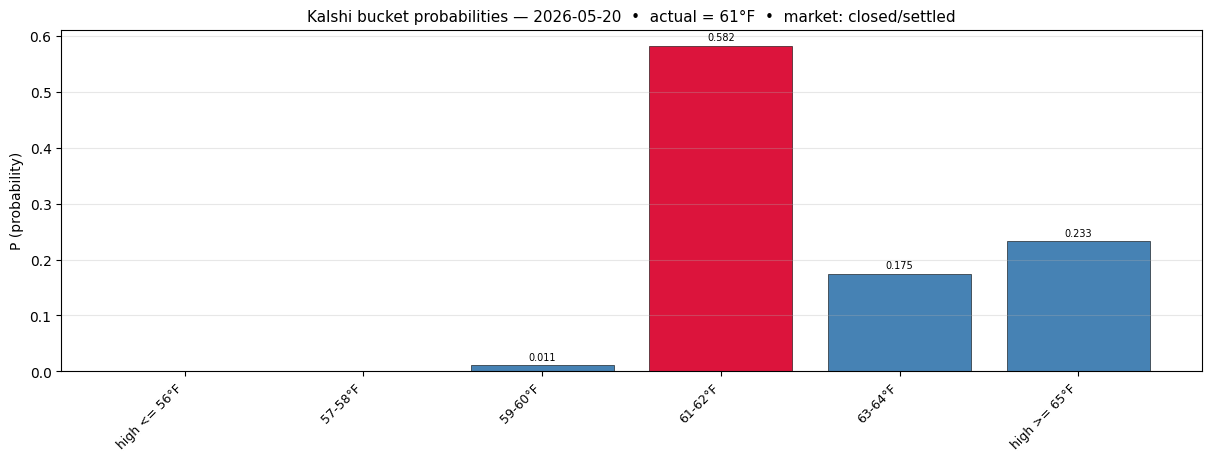

In [113]:
# === §5 — Fetch live Kalshi market + per-contract model P + live chart ===
# Reuses live.ipynb's fetch_kalshi_market via dynamic-exec (zero duplication).
# Applies a status / live-quote filter so settled events don't poison §6 with
# 0¢/100¢ dummy quotes. Always plots the Kalshi-bucket chart using THE LIVE
# bucket layout from Kalshi (Option A — single source of truth, no offline
# median-derived K mismatch).
import re

with open("live.ipynb", "r", encoding="utf-8") as _f:
    _live_nb = json.load(_f)
_kalshi_cell_src = None
for _c in _live_nb["cells"]:
    if _c["cell_type"] == "code" and "def fetch_kalshi_market(" in "".join(_c["source"]):
        _kalshi_cell_src = "".join(_c["source"])
        break
if _kalshi_cell_src is None:
    raise RuntimeError("Could not locate fetch_kalshi_market in live.ipynb")
KALSHI_API = "https://api.elections.kalshi.com/trade-api/v2"
exec(compile(_kalshi_cell_src, "<live.ipynb::fetch_kalshi_market>", "exec"), globals())


def _parse_kalshi_subtitle(sub):
    """Parse a Kalshi KXHIGHCHI subtitle into a bucket spec parseable by
    _parse_bucket(). Handles the four known KXHIGHCHI formats:

      - "X° to Y°"          -> "X-Y"  (B-pair range, the 4 middle contracts)
      - "X° or below"        -> "<=X"  (low T-edge contract)
      - "X° or above"        -> ">=X"  (high T-edge contract)
      - "below X°" / "above X°" -> "<X" / ">X" (older phrasings)

    Returns None if the subtitle doesn't match any known pattern.
    """
    s = (sub or "").strip().lower()
    if not s:
        return None
    m = re.match(r"(-?\d+)\D+to\D+(-?\d+)", s)
    if m:
        return f"{m.group(1)}-{m.group(2)}"
    m = re.match(r"(-?\d+)\D+(?:or|and)\s+below", s)
    if m:
        return f"<={m.group(1)}"
    m = re.match(r"(-?\d+)\D+(?:or|and)\s+above", s)
    if m:
        return f">={m.group(1)}"
    m = re.match(r"below\D+(-?\d+)", s)
    if m:
        return f"<{m.group(1)}"
    m = re.match(r"above\D+(-?\d+)", s)
    if m:
        return f">{m.group(1)}"
    return None


def _kalshi_to_bucket_spec(row):
    """Subtitle-first parser; falls back to strike_type/strike fields."""
    spec = _parse_kalshi_subtitle(row.get("subtitle"))
    if spec is not None:
        return spec
    st = row.get("strike_type")
    strike = row.get("strike")
    if st == "less" and pd.notna(strike):
        return f"<{int(strike)}"
    if st == "greater" and pd.notna(strike):
        return f">{int(strike)}"
    raise ValueError(
        f"Cannot parse Kalshi bucket: subtitle={row.get('subtitle')!r}, "
        f"strike_type={st!r}, strike={strike!r}, ticker={row.get('ticker')!r}"
    )


LIVE_STATUSES = {"open", "active"}

kalshi_market_df = fetch_kalshi_market(ANCHOR_DATE)
n_live = 0

if kalshi_market_df.empty:
    print(f"No Kalshi KXHIGHCHI event for {pd.Timestamp(ANCHOR_DATE).date()} "
          f"(event ticker may not be listed yet, or this date is fully settled and dropped).")
    kalshi_market_df = None
else:
    # Map every contract to a bucket spec + model P (regardless of status)
    kalshi_market_df["bucket_spec"] = kalshi_market_df.apply(_kalshi_to_bucket_spec, axis=1)

    _pmf = _result["pmf"]
    _p_models = []
    for _spec in kalshi_market_df["bucket_spec"]:
        _pred, _ = _parse_bucket(_spec)
        _mask = np.array([_pred(int(f)) for f in _pmf.index])
        _p_models.append(float(_pmf.values[_mask].sum()))
    kalshi_market_df["p_model"] = _p_models

    # Convert cent fields to dollars
    for _side in ("yes_bid", "yes_ask", "no_bid", "no_ask"):
        kalshi_market_df[_side] = kalshi_market_df[f"{_side}_cents"] / 100.0
    kalshi_market_df["yes_mid"]    = (kalshi_market_df["yes_bid"] + kalshi_market_df["yes_ask"]) / 2
    kalshi_market_df["no_mid"]     = (kalshi_market_df["no_bid"]  + kalshi_market_df["no_ask"])  / 2
    kalshi_market_df["last_price"] = kalshi_market_df["last_price_cents"] / 100.0

    # === Status / live-quote filter ===
    _status_lower = kalshi_market_df["status"].astype(str).str.lower()
    kalshi_market_df["is_live"] = _status_lower.isin(LIVE_STATUSES)
    n_live = int(kalshi_market_df["is_live"].sum())

    print(f"Kalshi KXHIGHCHI for {pd.Timestamp(ANCHOR_DATE).date()} "
          f"({len(kalshi_market_df)} contracts; model={MODEL}):")
    _show_cols = ["bucket_spec", "status", "yes_bid", "yes_ask",
                  "last_price", "p_model", "is_live"]
    print(kalshi_market_df[_show_cols].round(4).to_string(index=False))
    print(f"\n  Sum of p_model across {len(kalshi_market_df)} buckets: "
          f"{kalshi_market_df['p_model'].sum():.4f}")
    print(f"  Live contracts (status in {sorted(LIVE_STATUSES)}): "
          f"{n_live} / {len(kalshi_market_df)}")
    if n_live == 0:
        print("  -> Market is closed/settled; §6 edge analysis will be skipped.")

    # === Plot the live Kalshi bucket chart (replaces the old offline §4.4) ===
    import matplotlib.pyplot as plt
    _bucket_list = kalshi_market_df["bucket_spec"].tolist()
    _actual_row = target_df.loc[target_df["date"] == pd.Timestamp(ANCHOR_DATE), "cli_high"]
    _actual = _actual_row.iloc[0] if len(_actual_row) else None
    if _actual is not None and pd.isna(_actual):
        _actual = None
    _status_note = "market: open" if n_live > 0 else "market: closed/settled"
    _ax, _bdf = plot_kalshi_buckets_local(
        _pmf, ANCHOR_DATE, _actual, _bucket_list, status_note=_status_note,
    )
    plt.show()


## §6 — Edge analysis + trade decision

For each Kalshi contract, computes:
- `mid_edge` = P_model − yes_mid (positive = market underpricing YES side)
- `ev_yes`   = P_model − yes_ask (EV of buying YES at ask, ignoring fees)
- `ev_no`    = (1 − P_model) − no_ask (EV of buying NO at ask, ignoring fees)
- `best_side`, `best_ev` = which side has the higher EV
- `trade`    = `best_ev >= EDGE_THRESHOLD`

`EDGE_THRESHOLD` defaults to 0.03 (≥ 3¢ EV per contract) — a rough buffer
for Kalshi's per-trade fee (~7% × N × P × (1−P), rounded up to nearest cent).
Tune as you collect log data.

In [114]:
# === §6 — Edge analysis + trade decision (live markets only) ===
EDGE_THRESHOLD = 0.03  # require >= 3 cents EV per contract to flag a trade

if kalshi_market_df is None:
    print("No Kalshi market state -- skipping edge analysis.")
    edge_df = None
elif n_live == 0:
    print(f"All {len(kalshi_market_df)} contracts are closed/settled on "
          f"{pd.Timestamp(ANCHOR_DATE).date()}; no live two-sided market.")
    print("Skipping EV math. To exercise the trading layer, run live_predict "
          "during an open KXHIGHCHI window (intra-day, before midnight ET).")
    edge_df = None
else:
    edge_df = kalshi_market_df[kalshi_market_df["is_live"]].copy()
    edge_df["mid_edge"]    = edge_df["p_model"] - edge_df["yes_mid"]
    edge_df["ev_yes"]      = edge_df["p_model"] - edge_df["yes_ask"]
    edge_df["ev_no"]       = (1 - edge_df["p_model"]) - edge_df["no_ask"]
    edge_df["best_side"]   = np.where(edge_df["ev_yes"] >= edge_df["ev_no"], "YES", "NO")
    edge_df["best_ev"]     = edge_df[["ev_yes", "ev_no"]].max(axis=1)
    edge_df["entry_price"] = np.where(
        edge_df["best_side"] == "YES", edge_df["yes_ask"], edge_df["no_ask"]
    )
    edge_df["trade"] = edge_df["best_ev"] >= EDGE_THRESHOLD

    print(f"Edge analysis ({n_live} live contract(s), model={MODEL}, "
          f"threshold = {EDGE_THRESHOLD:.2f}):")
    _cols = ["bucket_spec", "p_model", "yes_ask", "no_ask",
             "mid_edge", "ev_yes", "ev_no", "best_side", "best_ev", "trade"]
    print(edge_df[_cols].round(4).to_string(index=False))

    _n_trades = int(edge_df["trade"].sum())
    print(f"\n{_n_trades} contract(s) clear the edge threshold of {EDGE_THRESHOLD:.2f}.")
    if _n_trades:
        print("\nTrade candidates:")
        for _, _r in edge_df[edge_df["trade"]].iterrows():
            print(f"  -> {_r['best_side']:3s} {_r['bucket_spec']:>8s}  "
                  f"entry={_r['entry_price']:.2f}  "
                  f"P_model={_r['p_model']:.3f}  "
                  f"EV={_r['best_ev']*100:+.1f}¢/contract")


All 6 contracts are closed/settled on 2026-05-20; no live two-sided market.
Skipping EV math. To exercise the trading layer, run live_predict during an open KXHIGHCHI window (intra-day, before midnight ET).


## §7 — Log per-contract decisions to `data/live_log.parquet`

Appends one row per Kalshi contract per prediction run. Schema covers the
inputs (run timestamp, model, anchor, market state, P_model), the derived
edge fields, and the decision flag. Useful for:
- Backtesting threshold choices once contracts settle
- Tracking calibration drift across paper-trading days
- Auditing trade decisions after the fact

In [115]:
# === §7 — Log per-contract rows to data/live_log.parquet ===
# Logs ALL contracts (live or settled). The status / is_live / last_price
# columns let downstream backtests filter to whichever subset you want.
LOG_PATH = DATA_DIR / "live_log.parquet"

if kalshi_market_df is None:
    print("No Kalshi market to log.")
else:
    _log = kalshi_market_df.copy()
    _log["run_utc"]        = pd.Timestamp.now(tz="UTC")
    _log["anchor_date"]    = pd.Timestamp(ANCHOR_DATE)
    _log["model"]          = MODEL
    _log["t_utc"]          = _T_utc_for(ANCHOR_DATE)
    _log["model_median"]   = _result["median"]
    _log["model_lo10"]     = _result["lo10"]
    _log["model_hi90"]     = _result["hi90"]
    _log["edge_threshold"] = EDGE_THRESHOLD

    # Merge in edge fields where computed (NaN for non-live contracts).
    _edge_cols = ["mid_edge", "ev_yes", "ev_no", "best_side",
                  "entry_price", "best_ev", "trade"]
    if edge_df is not None:
        _log = _log.merge(
            edge_df[["ticker"] + _edge_cols], on="ticker", how="left"
        )
    else:
        for _c in _edge_cols:
            _log[_c] = pd.NA

    _keep = ["run_utc", "anchor_date", "model", "t_utc",
             "model_median", "model_lo10", "model_hi90",
             "ticker", "strike_type", "strike", "subtitle", "bucket_spec",
             "status", "is_live",
             "yes_bid", "yes_ask", "no_bid", "no_ask", "yes_mid", "no_mid",
             "last_price", "p_model",
             "mid_edge", "ev_yes", "ev_no",
             "best_side", "entry_price", "best_ev", "trade", "edge_threshold"]
    _log = _log[_keep]

    if LOG_PATH.exists():
        _existing = pd.read_parquet(LOG_PATH)
        # concat handles column mismatch (older rows get NaN for new columns)
        _combined = pd.concat([_existing, _log], ignore_index=True, sort=False)
    else:
        _combined = _log
    _combined.to_parquet(LOG_PATH)
    print(f"Appended {len(_log)} row(s) to {LOG_PATH} -- total now {len(_combined)} rows.")
    _n_live_logged = int(_log["is_live"].sum())
    print(f"  live contracts logged this run: {_n_live_logged} / {len(_log)}")


Appended 6 row(s) to data\live_log.parquet -- total now 18 rows.
  live contracts logged this run: 0 / 6
